# Polynomial Regression
- implementing polynomial regression with different degrees
- The data shows a nonlinear curved trend that can be captured with polynomial terms.
- Extends linear regression by adding polynomial features (x², x³...).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [2]:
df = pd.read_csv('./cleaned_property_data.csv')

In [3]:
X = df.drop(columns=["Super Buildup Rate (per sq.ft.)"], errors="ignore")
y = df["Super Buildup Rate (per sq.ft.)"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### with degree = 2

In [4]:
degree = 2  

# Create polynomial features
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [5]:
# Fit linear regression on polynomial features
model = LinearRegression()
model.fit(X_train_poly, y_train)

LinearRegression()

In [8]:
# Predict and evaluate
y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

train_r2 = r2_score(y_train, model.predict(X_train_poly))

print(f"Polynomial Regression (degree={degree}) Results")
print(f"RMSE: {rmse:.2f}")
print(f"MSE: {mse:.2f}")
print(f"Test R² Score: {r2:.4f}")
print(f"Train R² Score: {train_r2:.4f}")

Polynomial Regression (degree=3) Results
RMSE: 0.04
MSE: 0.00
Test R² Score: 0.9986
Train R² Score: 0.9990


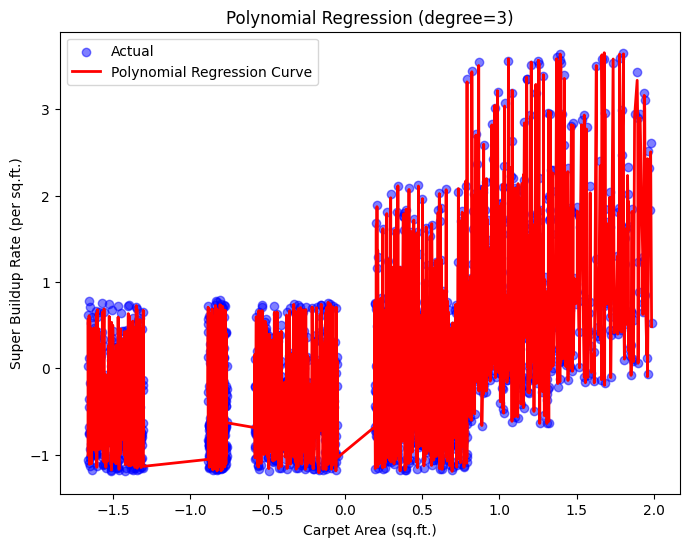

In [7]:
feature = "Carpet Area (sq.ft.)"  
X_plot = X_test[[feature]].values

# Sort for smooth curve
sort_idx = np.argsort(X_plot.ravel())
X_sorted = X_plot[sort_idx]
y_test_sorted = y_test.values[sort_idx]
y_pred_sorted = y_pred[sort_idx]

plt.figure(figsize=(8,6))
plt.scatter(X_test[feature], y_test, color='blue', alpha=0.5, label='Actual')
plt.plot(X_sorted, y_pred_sorted, color='red', linewidth=2, label='Polynomial Regression Curve')
plt.xlabel(feature)
plt.ylabel("Super Buildup Rate (per sq.ft.)")
plt.title(f"Polynomial Regression (degree={degree})")
plt.legend()
plt.show()

- seems look like overfitting

In [ ]:
degrees = [1, 2, 3, 4]
results = []

for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    y_pred = model.predict(X_test_poly)
    
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({'degree': degree, 'RMSE': rmse, 'MAE': mae, 'MSE': mse , 'R2': r2})

# Optionally, display all results as a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

- shows error of memory out of bound

#### With degree = 3

In [6]:
degree = 3

poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_pred = model.predict(X_test_poly)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Polynomial Regression (degree={degree}) Results")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Polynomial Regression (degree=3) Results
RMSE: 0.04
R² Score: 0.9986


In [9]:
train_r2 = r2_score(y_train, model.predict(X_train_poly))
print(f"Train R² Score: {train_r2:.4f}")

Train R² Score: 0.9990


- accuracy increases with increasing degree, but we need tune the parameters as higher the degree -> higher risk of overfitting.